In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import time

df = pd.read_csv('Homework_3_Dataset_Smart_home 1.csv')

In [2]:
df['Next Time'] = df['Time'].shift(-1)
df['Next Electricity Price'] = df['Electricity Price'].shift(-1)
df['Next User Activity'] = df['User Activity'].shift(-1)
last_index = df.index[-1]
first_index = df.index[0]
df.loc[last_index, 'Next Time'] = df.loc[first_index, 'Time']
df.loc[last_index, 'Next Electricity Price'] = df.loc[first_index, 'Electricity Price']
df.loc[last_index, 'Next User Activity'] = df.loc[first_index, 'User Activity']
df['Next Time'] = df['Next Time'].astype(int)
df['Next User Activity'] = df['Next User Activity'].astype(int)

n_times = 24
n_user_states = 2
n_appliance_states = 2
n_actions = 2 # 0: OFF, 1: ON

n_states = n_times * n_user_states * n_appliance_states

In [3]:
def state_to_index(t, u, app_state):
    return t * (n_user_states * n_appliance_states) + u * n_appliance_states + app_state

def index_to_state(index):
    app_state = index % n_appliance_states
    index //= n_appliance_states
    u = index % n_user_states
    index //= n_user_states
    t = index
    return t, u, app_state

start_model_time = time.time()
avg_price = df.groupby('Time')['Electricity Price'].mean().to_numpy()
prob_user_active = df.groupby('Time')['User Activity'].mean().to_numpy()
comfort_penalty = 1.0

In [4]:
R = np.zeros((n_states, n_actions))
for s_idx in range(n_states):
    t, u, app_state = index_to_state(s_idx)
    next_t = (t + 1) % n_times
    expected_reward_off = prob_user_active[next_t] * (-comfort_penalty)
    R[s_idx, 0] = expected_reward_off
    expected_reward_on = -avg_price[next_t]
    R[s_idx, 1] = expected_reward_on

P = np.zeros((n_states, n_actions, n_states))
for s_idx in range(n_states):
    t, u, app_state = index_to_state(s_idx)
    next_t = (t + 1) % n_times
    for a in range(n_actions):
        next_app_state = a 
        s_prime_idx_0 = state_to_index(next_t, 0, next_app_state)
        prob_next_user_inactive = 1.0 - prob_user_active[next_t]
        P[s_idx, a, s_prime_idx_0] = prob_next_user_inactive
        s_prime_idx_1 = state_to_index(next_t, 1, next_app_state)
        prob_next_user_is_active = prob_user_active[next_t]
        P[s_idx, a, s_prime_idx_1] = prob_next_user_is_active

end_model_time = time.time()
print(f"Model learning finished in {end_model_time - start_model_time:.2f} seconds.")

Model learning finished in 65.41 seconds.


In [5]:
print("\nStarting Value Iteration...")
start_vi_time = time.time()

gamma = 0.95 
theta = 1e-5
V = np.zeros(n_states)
iterations = 0
max_iterations = 5000

while iterations < max_iterations:
    delta = 0
    V_old = V.copy()

    for s_idx in range(n_states):
        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            expected_future_value = 0
            for s_prime_idx in range(n_states):
                 expected_future_value += P[s_idx, a, s_prime_idx] * V_old[s_prime_idx]
            q_values[a] = R[s_idx, a] + gamma * expected_future_value
        V[s_idx] = np.max(q_values)
    delta = np.max(np.abs(V - V_old))
    iterations += 1
    if delta < theta:
        print(f"Value Iteration converged after {iterations} iterations.")
        break
    if iterations % 100 == 0:
         print(f"Iteration {iterations}, Delta: {delta}")

if iterations == max_iterations:
    print(f"Value Iteration did not converge within {max_iterations} iterations. Delta: {delta}")

end_vi_time = time.time()
print(f"Value Iteration finished in {end_vi_time - start_vi_time:.2f} seconds.")


Starting Value Iteration...
Iteration 100, Delta: 0.0020316763429786278
Iteration 200, Delta: 1.2028599154056963e-05
Value Iteration converged after 204 iterations.
Value Iteration finished in 3.01 seconds.


In [6]:
policy = np.zeros(n_states, dtype=int)
for s_idx in range(n_states):
    q_values = np.zeros(n_actions)
    for a in range(n_actions):
        expected_future_value = 0
        for s_prime_idx in range(n_states):
            expected_future_value += P[s_idx, a, s_prime_idx] * V[s_prime_idx]
        q_values[a] = R[s_idx, a] + gamma * expected_future_value
    policy[s_idx] = np.argmax(q_values)

print("\nOptimal policy extracted.")


Optimal policy extracted.


In [7]:
print("\nEvaluating learned policy...")
model_based_total_cost = 0
model_based_comfort_violations = 0
model_based_schedule = []
current_appliance_state = 0 # Start OFF
model_based_cumulative_reward_eval = 0

for index, row in df.iterrows():
    current_time = int(row['Time'])
    current_user_activity = int(row['User Activity'])
    next_user_activity = int(row['Next User Activity'])
    next_price = row['Next Electricity Price']

    current_state_idx = state_to_index(current_time, current_user_activity, current_appliance_state)

    action = policy[current_state_idx]
    model_based_schedule.append(action)

    next_appliance_state_actual = action

    reward = 0
    if next_appliance_state_actual == 1:
        cost_incurred = next_price
        model_based_total_cost += cost_incurred
        reward = -cost_incurred
    else:
        if next_user_activity == 1:
            model_based_comfort_violations += 1
            reward = -comfort_penalty

    model_based_cumulative_reward_eval += reward
    current_appliance_state = next_appliance_state_actual

print("\nModel-Based (Value Iteration) Evaluation Results:")
print(f"  Total Electricity Cost: ${model_based_total_cost:.2f}")
print(f"  Number of Comfort Violations: {model_based_comfort_violations}")
print(f"  Total Reward: {model_based_cumulative_reward_eval:.2f}")


Evaluating learned policy...

Model-Based (Value Iteration) Evaluation Results:
  Total Electricity Cost: $120.86
  Number of Comfort Violations: 36
  Total Reward: -156.86



--- Baselines & Q-Learning Comparison ---
Baseline (Always ON): Cost=$165.83, Violations=0, Reward=-165.83
Baseline (Always OFF): Cost=$0.00, Violations=328, Reward=-328.00
Baseline (ON if Active Next): Cost=$76.74, Violations=0, Reward=-76.74
Q-Learning (Penalty=1.0, Approx): Cost=$150.49, Violations=7, Reward=-157.49

--- Cost Comparison Visualization ---


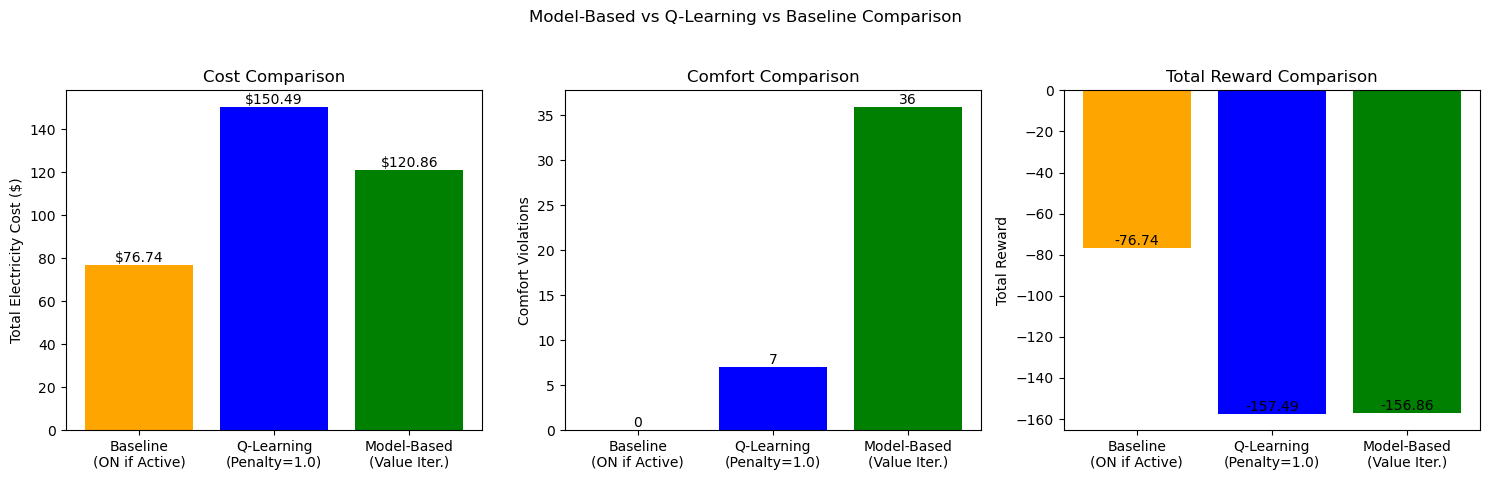

In [8]:
print("\n--- Baselines & Q-Learning Comparison ---")
cost_always_on = df['Next Electricity Price'].sum()
violations_always_on = 0
reward_always_on = -cost_always_on
print(f"Baseline (Always ON): Cost=${cost_always_on:.2f}, Violations={violations_always_on}, Reward={reward_always_on:.2f}")

cost_always_off = 0
violations_always_off = df[df['Next User Activity'] == 1].shape[0]
reward_always_off = - (violations_always_off * comfort_penalty)
print(f"Baseline (Always OFF): Cost=${cost_always_off:.2f}, Violations={violations_always_off}, Reward={reward_always_off:.2f}")

cost_baseline_active = df.loc[df['Next User Activity'] == 1, 'Next Electricity Price'].sum()
violations_baseline_active = 0
reward_baseline_active = - cost_baseline_active
print(f"Baseline (ON if Active Next): Cost=${cost_baseline_active:.2f}, Violations={violations_baseline_active}, Reward={reward_baseline_active:.2f}")

q_learning_cost = 150.49
q_learning_violations = 7
q_learning_reward = -157.49
print(f"Q-Learning (Penalty={comfort_penalty:.1f}, Approx): Cost=${q_learning_cost:.2f}, Violations={q_learning_violations}, Reward={q_learning_reward:.2f}")

print("\n--- Cost Comparison Visualization ---")
scenarios = ['Baseline\n(ON if Active)', f'Q-Learning\n(Penalty={comfort_penalty:.1f})', 'Model-Based\n(Value Iter.)']
costs = [cost_baseline_active, q_learning_cost, model_based_total_cost]
rewards = [reward_baseline_active, q_learning_reward, model_based_cumulative_reward_eval]
violations = [violations_baseline_active, q_learning_violations, model_based_comfort_violations]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Cost Plot
axs[0].bar(scenarios, costs, color=['orange', 'blue', 'green'])
axs[0].set_ylabel('Total Electricity Cost ($)')
axs[0].set_title('Cost Comparison')
for i, bar in enumerate(axs[0].patches):
    yval = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'${yval:.2f}', va='bottom', ha='center')

# Violation Plot
axs[1].bar(scenarios, violations, color=['orange', 'blue', 'green'])
axs[1].set_ylabel('Comfort Violations')
axs[1].set_title('Comfort Comparison')
for i, bar in enumerate(axs[1].patches):
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{int(yval)}', va='bottom', ha='center')

# Reward Plot
axs[2].bar(scenarios, rewards, color=['orange', 'blue', 'green'])
axs[2].set_ylabel('Total Reward')
axs[2].set_title('Total Reward Comparison')
for i, bar in enumerate(axs[2].patches):
    yval = bar.get_height()
    axs[2].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom', ha='center')


plt.suptitle('Model-Based vs Q-Learning vs Baseline Comparison')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()